# Regression

Regression in machine learning is the task of predicting a continuous numerical value for each input based on learned patterns from labeled training data. Predicting the price of a house from its features such as size, location, and number of rooms is a regression problem.

Building a regression model is similar to classification in many ways, but there are also key differences. Let’s train our first regression model and see how it compares to what we learned in classification.

## 1. Your first regression model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# load the dataset
# the target, y, is continuous, so this is suitable for a regression problem
from sklearn.datasets import load_diabetes
X, y = load_diabetes(as_frame=True, return_X_y=True)

The goal is to predict a quantitative measure of diabetes progression one year after the baseline. It has 10 features such as age, sex, body mass index (BMI), blood pressure, and blood serum measurements.

Remember: unlike classification datasets, the target (y) here is continuous, it can take many values, not just 0 or 1.

In [3]:
# instead of importing RandomForestClassifier
# we import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(random_state=0)

In [4]:
# same as classification
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [5]:
# same as classification
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of

In [6]:
# Same as classification,
# but now the output values are continuous numbers.
y_pred = model.predict(X_test)
y_pred

array([249.77, 237.06, 173.44, 110.9 , 214.83, 268.97,  96.11, 210.42,
       145.59, 245.27, 173.51, 146.31, 131.37,  99.04, 274.61,  84.17,
       166.55,  82.06, 116.32, 208.43, 174.46, 134.4 , 179.6 , 120.47,
       207.11, 193.46, 146.17,  74.95, 194.32, 168.62, 182.36,  73.27,
       117.48, 150.84, 140.29, 171.14, 167.36, 149.67,  94.26, 213.24,
       107.22, 164.27, 117.81, 186.5 , 192.07,  87.66, 129.8 , 134.4 ,
       109.53, 236.78, 160.93,  67.58, 155.66, 162.49, 240.94, 197.51,
       178.46,  85.3 , 126.57, 163.15, 240.76, 145.89, 123.13,  96.55,
       266.96, 156.54,  97.13, 227.93, 215.67, 118.82,  83.68, 147.32,
       124.48, 119.23, 126.9 , 181.13, 123.59, 225.33, 245.61, 215.59,
       119.85, 186.75,  69.72, 239.35, 111.09,  92.45, 151.87, 194.59,
        99.81])

This changes how we evaluate the model. A simple way to see how well it performs is to plot predictions vs. true labels on a scatter plot.

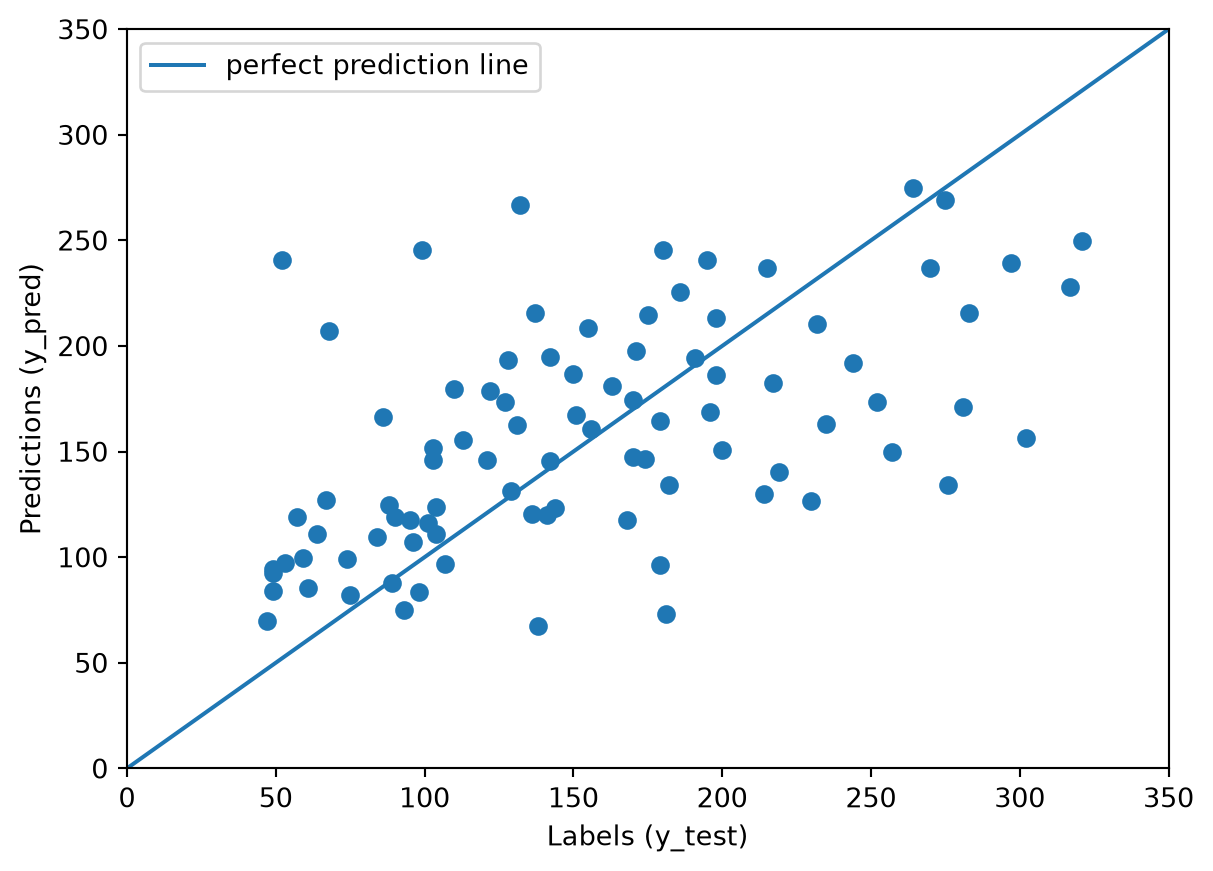

In [7]:
plt.scatter(y_test, y_pred)
plt.xlim(0, 350)
plt.ylim(0, 350)
plt.plot([0, 350], [0, 350], label='perfect prediction line')
plt.xlabel("Labels (y_test)")
plt.ylabel("Predictions (y_pred)")
plt.legend()

Points close to the line are great (perfect if exactly on the line). Points far from the line are poor. To measure performance, we can check the average difference between predictions and true values, which is the error.

In [8]:
error = y_pred - y_test
error

362   -71.23
249    22.06
271    46.44
435    46.90
400    39.83
       ...  
381     7.09
213    43.45
134    48.87
49     52.59
52     40.81
Name: target, Length: 89, dtype: float64

We could take the average error, but positive and negative values would cancel out. For example, +100 and -100 average to 0, which hides the real error.

In [9]:
# very low comparing to the errors we see in the plot
# which is due to positive and negative errors cancelling each other
np.mean(error)

np.float64(3.534269662921351)

To fix this, we take the absolute value of each error.

In [10]:
np.abs(error)

362    71.23
249    22.06
271    46.44
435    46.90
400    39.83
       ...  
381     7.09
213    43.45
134    48.87
49     52.59
52     40.81
Name: target, Length: 89, dtype: float64

Then we take the mean, this gives us an error value that actually makes sense.

In [11]:
np.mean(np.abs(error))

np.float64(47.75224719101124)

this is called the mean absolute error (MAE). You can tell from the code:

np.<mark>mean</mark>(np.<mark>abs</mark>(<mark>error</mark>))

and you guessed it right, it is already implemented in scikit-learn

<mark>YOUR TURN</mark>

Calculate MAE using scikit-learn's implemented method, you should obtain the same value you obtained above.

In [12]:
# YOUR CODE HERE

My MAE was 47.75, yours might differ slightly due to randomness.

## 2. Baselines

Is this a good model? What does a **MAE of ~48** even mean?

In **classification**, model performance is easier to interpret, for example, an accuracy of 90% sounds good because we know that for a **binary** and **balanced** problem, random guessing gives about **50% accuracy** (like flipping a coin). So, 90% is clearly much better than chance.

In **regression**, interpretation depends on the **domain**. If you’re predicting **house prices**, a **$1,000** error might be excellent, while a **$100,000** error would be terrible. The meaning of the error depends entirely on the scale of the target variable.

When we **don’t know the domain**, a useful baseline is to **predict the average of all targets** and measure the resulting MAE. This baseline acts like the “coin flip” in classification, if your model doesn’t perform better than this, it isn’t learning anything meaningful.

In [13]:
# the average of y_test
y_test.mean()

np.float64(154.22471910112358)

In [14]:
# predict everything as the average of y_test
y_pred_baseline = np.ones_like(y_test)*y_test.mean()
y_pred_baseline

array([154.2247191, 154.2247191, 154.2247191, 154.2247191, 154.2247191,
       154.2247191, 154.2247191, 154.2247191, 154.2247191, 154.2247191,
       154.2247191, 154.2247191, 154.2247191, 154.2247191, 154.2247191,
       154.2247191, 154.2247191, 154.2247191, 154.2247191, 154.2247191,
       154.2247191, 154.2247191, 154.2247191, 154.2247191, 154.2247191,
       154.2247191, 154.2247191, 154.2247191, 154.2247191, 154.2247191,
       154.2247191, 154.2247191, 154.2247191, 154.2247191, 154.2247191,
       154.2247191, 154.2247191, 154.2247191, 154.2247191, 154.2247191,
       154.2247191, 154.2247191, 154.2247191, 154.2247191, 154.2247191,
       154.2247191, 154.2247191, 154.2247191, 154.2247191, 154.2247191,
       154.2247191, 154.2247191, 154.2247191, 154.2247191, 154.2247191,
       154.2247191, 154.2247191, 154.2247191, 154.2247191, 154.2247191,
       154.2247191, 154.2247191, 154.2247191, 154.2247191, 154.2247191,
       154.2247191, 154.2247191, 154.2247191, 154.2247191, 154.2

In [15]:
from sklearn.metrics import mean_absolute_error
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
mae_baseline

59.43340487312208

My baseline error was 59.43, and the model's error was 47.75, much better! So, the model is clearly learning some useful relationships. A perfect model would achieve a MAE of zero, so this model is still far from a perfect model.

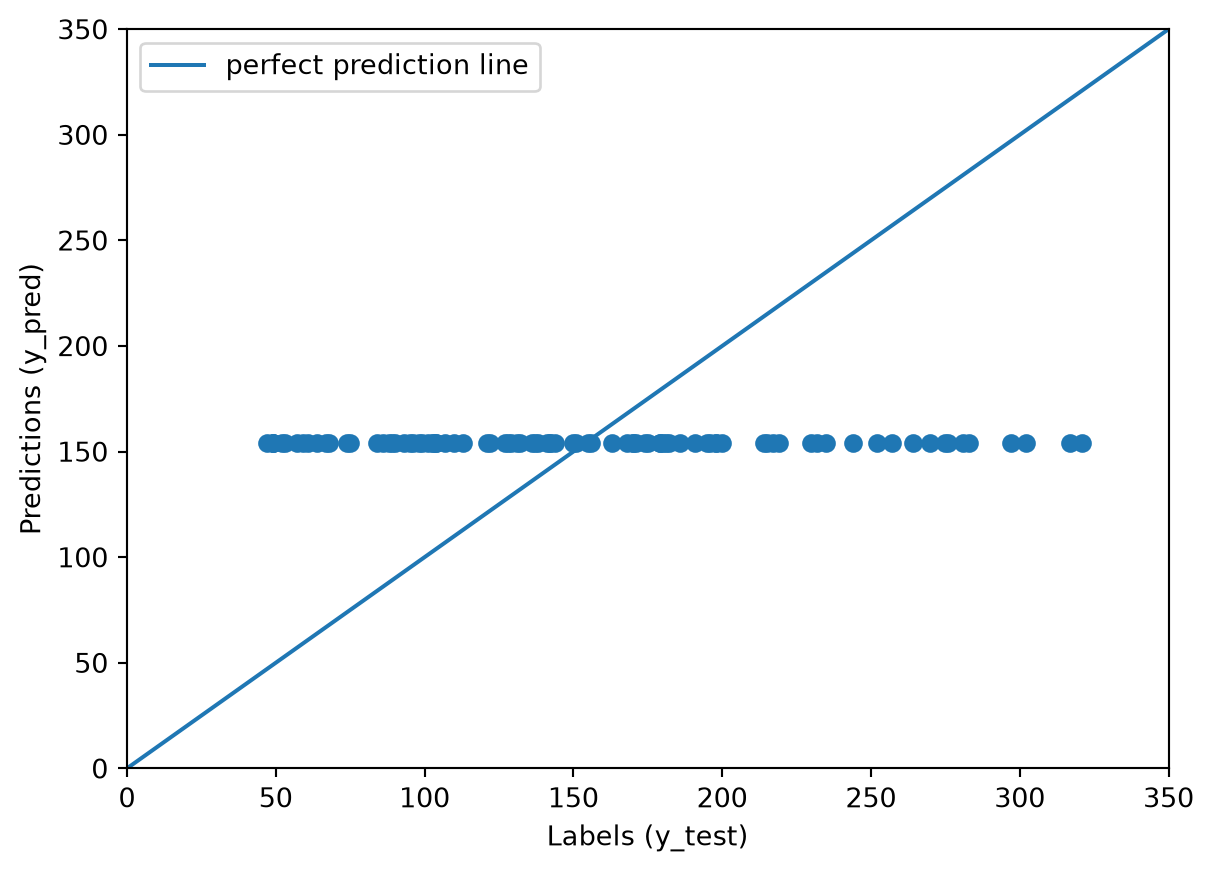

In [16]:
# how predicting every datapoint as the mean looks like
plt.scatter(y_test, y_pred_baseline)
plt.xlim(0, 350)
plt.ylim(0, 350)
plt.plot([0, 350], [0, 350], label='perfect prediction line')
plt.xlabel("Labels (y_test)")
plt.ylabel("Predictions (y_pred)")
plt.legend()

## 3. Exercise

<mark>YOUR TURN</mark>

Train and test a regression model based on the California Housing Dataset to predict the price of a house from its properties

In [17]:
from sklearn.datasets import fetch_california_housing
X, y = fetch_california_housing(as_frame=True, return_X_y=True)

In [18]:
# YOUR CODE HERE

What is the MAE of your model in 💵? It should be roughly **$30–40K**. Always check the documentation to understand what the target variable (`y`) actually represents.